In [1]:
import os
import random
import numpy as np
import h5py
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau



print("GPU:", tf.config.list_physical_devices('GPU'))



data_path = "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data"

files = [f for f in os.listdir(data_path) if f.endswith('.h5')]

print("Total samples:", len(files))




class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_list, batch_size=4):
        self.file_list = file_list
        self.batch_size = batch_size

    def __len__(self):
        return len(self.file_list) // self.batch_size

    def __getitem__(self, idx):
        batch_files = self.file_list[idx*self.batch_size:(idx+1)*self.batch_size]

        images, masks = [], []

        for file in batch_files:
            try:
                with h5py.File(os.path.join(data_path, file), 'r') as f:
                    images.append(f['image'][:])
                    masks.append(f['mask'][:])
            except:
                continue

        return np.array(images), np.array(masks)




random.shuffle(files)

train_files = files[:10000]
val_files = files[10000:12000]

train_gen = DataGenerator(train_files, batch_size=4)
val_gen = DataGenerator(val_files, batch_size=4)




def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )




def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    dice = 1 - dice_coefficient(y_true, y_pred)
    return ce + dice




def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x


def attention_block(x, g, filters):
    theta_x = Conv2D(filters, 1)(x)
    phi_g = Conv2D(filters, 1)(g)

    add = Add()([theta_x, phi_g])
    act = Activation('relu')(add)

    psi = Conv2D(1, 1)(act)
    psi = Activation('sigmoid')(psi)

    return Multiply()([x, psi])


def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = MaxPooling2D((2,2))(f)
    return f, p


def decoder_block(x, skip, filters):
    x = UpSampling2D((2,2))(x)
    skip = attention_block(skip, x, filters)
    x = Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x





def build_attention_unet():
    inputs = Input((240,240,4))

    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = conv_block(p4, 512)

    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = Conv2D(3, 1, activation='softmax')(d4)

    return Model(inputs, outputs)





model = build_attention_unet()

model.compile(
    optimizer='adam',
    loss=combined_loss,   # 🔥 FIXED
    metrics=[dice_coefficient]   # 🔥 FIXED
)

model.summary()





checkpoint = ModelCheckpoint(
    "/kaggle/working/best_model.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)





history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[checkpoint, lr_scheduler]
)

2026-04-16 12:45:55.264348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776343555.485822      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776343555.549148      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776343556.068456      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776343556.068543      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776343556.068547      23 computation_placer.cc:177] computation placer alr

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Total samples: 57195


I0000 00:00:1776343584.097172      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776343584.103604      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 240,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 120, 120,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 60, 60,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 60, 60,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        512 │ conv2d_4[0][0]  

...

   1/2500 ━━━━━━━━━━━━━━━━━━━━ 29:05:28 42s/step - dice_coefficient: 0.0213 - loss: 1.0079

I0000 00:00:1776343627.937531      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - dice_coefficient: 0.0082 - loss: 1.0036

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 352s 124ms/step - dice_coefficient: 0.0082 - loss: 1.0036 - val_dice_coefficient: 0.0070 - val_loss: 1.0048 - learning_rate: 0.0010
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.0074 - loss: 1.0050

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 312s 125ms/step - dice_coefficient: 0.0074 - loss: 1.0050 - val_dice_coefficient: 0.0074 - val_loss: 1.0041 - learning_rate: 0.0010
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 309s 123ms/step - dice_coefficient: 0.0074 - loss: 1.0050 - val_dice_coefficient: 0.0070 - val_loss: 1.0048 - learning_rate: 0.0010
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - dice_coefficient: 0.0073 - loss: 1.0053
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 312s 125ms/step - dice_coefficient: 0.0073 - loss: 1.0053 - val_dice_coefficient: 0.0070 - val_loss: 1.0048 - learning_rate: 0.0010
Epoch 5/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 310s 124ms/step - dice_coefficient: 0.0074 - loss: 1.0050 - val_dice_coefficient: 0.0071 - val_loss: 1.0047 - learning_rate: 5.0000e-04


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


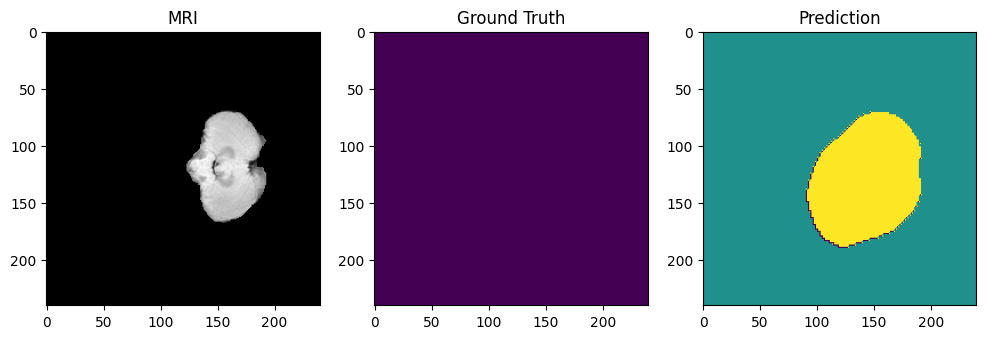

In [2]:
import matplotlib.pyplot as plt

test_file = random.choice(val_files)

with h5py.File(os.path.join(data_path, test_file), 'r') as f:
    image = f['image'][:]
    mask = f['mask'][:]

X = np.expand_dims(image, axis=0)

pred = model.predict(X)

pred_labels = np.argmax(pred[0], axis=-1)
gt = np.argmax(mask, axis=-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image[:,:,0], cmap='gray')
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(gt)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_labels)
plt.title("Prediction")

plt.show()
